# TD-2 Data Cleaning and Data Preprocessing (Adult Income Dataset)

This practical session is based on **CM2**.  
The goal is not to build a full machine learning pipeline. The main goal is to **inspect, clean, transform, and prepare data correctly**.

## Session plan

During this session, you will work through a complete data cleaning workflow:

1. Inspect the dataset and identify quality issues  
2. Handle missing values  
3. Detect and remove duplicates  
4. Inspect potential outliers with visual tools and the IQR rule  
5. Clean categories and data types  
6. Encode categorical variables  
7. Apply basic scaling to numerical variables  
8. Very briefly prepare a clean table for later machine learning use

### Expected work
For each exercise:
- read the question carefully;
- write the requested code;
- when asked, add a short comment to explain your choice.

### Important rule
Do **not** modify the original dataframe directly at the beginning.  
Always keep a raw copy and work on a separate cleaned dataframe.


In [33]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme()

## Part 0 — Load the dataset

We use the **Adult Income** dataset from OpenML.

### Tasks
1. Load the dataset into a dataframe called `adult_df`.
2. Display the first 5 rows.
3. Display the shape of the dataset.
4. Create a second dataframe called `df` that will be used for cleaning.


In [34]:

adult_df = fetch_openml("adult", version=2, as_frame=True).frame
adult_df.head()
adult_df.shape

df = adult_df.copy()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


(48842, 15)

## Part 1 — First inspection of the dataset

Before cleaning anything, we must understand what we are looking at.

### Tasks
1. Display general information about `df`.
2. Show the data types of all columns.
3. Count the missing values in each column.
4. Compute the percentage of missing values in each column.
5. Display descriptive statistics for numerical columns.
6. Display descriptive statistics for categorical columns.
7. Answer briefly: which columns seem to need attention first?


In [35]:

df.info()

df.dtypes

missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_pct

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

occupation        2809
workclass         2799
native-country     857
age                  0
fnlwgt               0
education            0
education-num        0
marital-status       0
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
class                0
dtype: int64

occupation        5.75
workclass         5.73
native-country    1.75
age               0.00
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
relationship      0.00
race              0.00
sex               0.00
capital-gain      0.00
capital-loss      0.00
hours-per-week    0.00
class             0.00
dtype: float64

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


**Short comment:**  
The columns that need attention first are the ones with missing values, especially `workclass`, `occupation`, and `native-country`.  
We should also inspect categorical columns carefully because the Adult dataset contains many text categories, and these are common sources of inconsistency during preprocessing.


## Part 1b — Quick visual inspection

A few simple plots can already reveal suspicious patterns.

### Tasks
1. Plot the distribution of `age`.
2. Plot the distribution of `hours-per-week`.
3. Draw a boxplot for `age`.
4. Draw a boxplot for `capital-gain`.
5. Write a short comment: which variable looks strongly skewed? Which one seems to contain many extreme values?


<Figure size 700x400 with 0 Axes>

<Axes: xlabel='age', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of age')

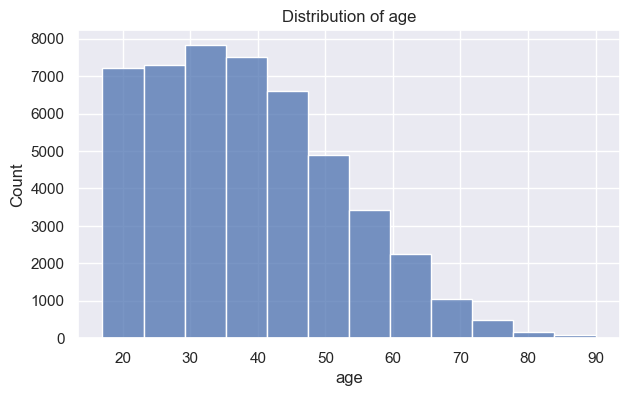

<Figure size 700x400 with 0 Axes>

<Axes: xlabel='hours-per-week', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of hours-per-week')

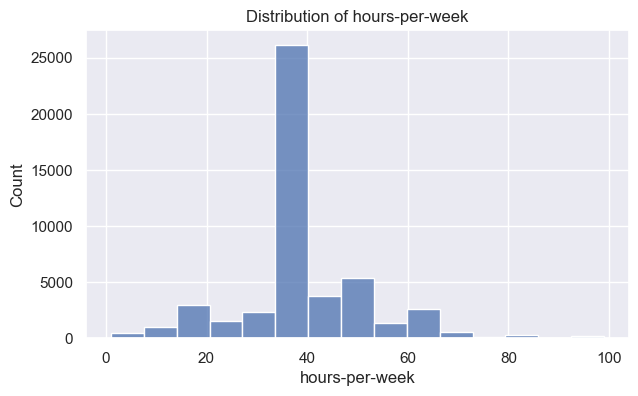

<Figure size 700x400 with 0 Axes>

<Axes: xlabel='age'>

Text(0.5, 1.0, 'Boxplot of age')

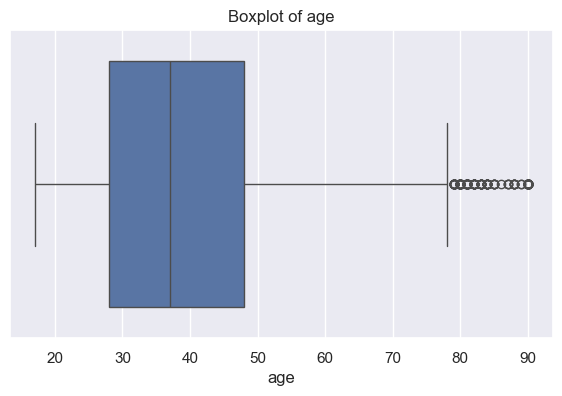

<Figure size 700x400 with 0 Axes>

<Axes: xlabel='capital-gain'>

Text(0.5, 1.0, 'Boxplot of capital-gain')

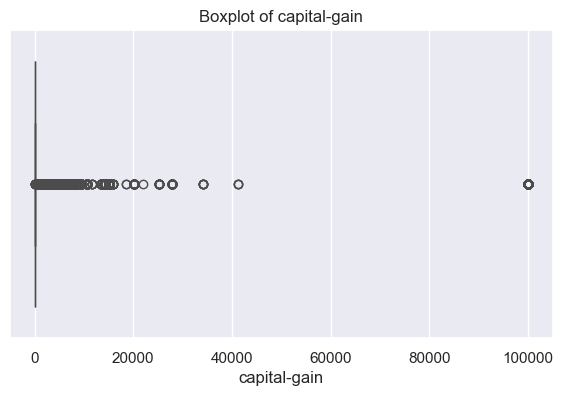

In [36]:

plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=12)
plt.title("Distribution of age")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df["hours-per-week"], bins=15)
plt.title("Distribution of hours-per-week")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x=df["age"])
plt.title("Boxplot of age")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x=df["capital-gain"])
plt.title("Boxplot of capital-gain")
plt.show()


**Short comment:**  
`capital-gain` is strongly skewed and contains many extreme values.  
`age` has a few high values, but the boxplot is much easier to interpret than the one for `capital-gain`.


## Part 2 — Missing values

In this dataset, some values are already represented as `NaN`.

### Tasks
1. Identify all columns that contain missing values.
2. Separate them into:
   - numerical columns with missing values;
   - categorical columns with missing values.
3. For each categorical column with missing values, display the number of missing values.
4. Create a copy called `df_missing_fixed`.
5. Replace missing values in categorical columns with the string `"Unknown"`.
6. Check that no missing values remain in these categorical columns.

### Question
Why is `"Unknown"` often a reasonable choice for categorical variables?


In [37]:

cols_with_missing = df.columns[df.isna().any()].tolist()
cols_with_missing

num_missing_cols = df[cols_with_missing].select_dtypes(include=np.number).columns.tolist()
cat_missing_cols = df[cols_with_missing].select_dtypes(exclude=np.number).columns.tolist()

num_missing_cols
cat_missing_cols

df[cat_missing_cols].isna().sum()

df_missing_fixed = df.copy()
for col in cat_missing_cols:
    if "Unknown" not in df_missing_fixed[col].cat.categories:
        df_missing_fixed[col] = df_missing_fixed[col].cat.add_categories("Unknown")
    df_missing_fixed[col] = df_missing_fixed[col].fillna("Unknown")

df_missing_fixed[cat_missing_cols].isna().sum()


['workclass', 'occupation', 'native-country']

[]

['workclass', 'occupation', 'native-country']

workclass         2799
occupation        2809
native-country     857
dtype: int64

workclass         0
occupation        0
native-country    0
dtype: int64

**Answer:**  
For a categorical variable, `"Unknown"` is often reasonable because it preserves all rows and makes the missing information explicit.  
This can be better than deleting rows immediately, especially when the missing value itself may be informative.


## Part 2b — Compare two imputation strategies on a small example

This section is here to make you think about **choice**, not only about code.

We create a small artificial numerical series and compare:
- mean imputation;
- median imputation.

### Tasks
1. Create the series shown below.
2. Compute the mean and the median of the observed values.
3. Fill missing values once with the mean and once with the median.
4. Compare the two results.
5. Write one sentence: which method is usually safer when a variable contains extreme values?


In [38]:

sample = pd.Series([10, 11, 12, np.nan, 13, 14, 1000, np.nan])
sample


0      10.0
1      11.0
2      12.0
3       NaN
4      13.0
5      14.0
6    1000.0
7       NaN
dtype: float64

In [39]:

sample_mean = sample.mean().round(2)
sample_median = sample.median()

sample_mean
sample_median

sample_fill_mean = sample.fillna(sample_mean)
sample_fill_median = sample.fillna(sample_median)

sample_fill_mean
sample_fill_median


176.67

12.5

0      10.00
1      11.00
2      12.00
3     176.67
4      13.00
5      14.00
6    1000.00
7     176.67
dtype: float64

0      10.0
1      11.0
2      12.0
3      12.5
4      13.0
5      14.0
6    1000.0
7      12.5
dtype: float64

**Answer:**  
The median is usually safer when the variable contains extreme values, because it is less sensitive to outliers.


## Part 3 — Duplicates

Even if a dataset looks clean, duplicated rows may exist.

### Tasks
1. Count the number of duplicated rows in the original dataset `df_missing_fixed`.
2. Display a few duplicated rows if there are any.
3. Create a cleaned dataframe called `df_no_duplicates` by removing duplicates.
4. Compare the shape before and after duplicate removal.
5. Write a short comment: when should we be careful before removing duplicates?


In [40]:

df_missing_fixed.duplicated().sum()

duplicated_rows = df_missing_fixed[df_missing_fixed.duplicated()]
duplicated_rows.head()

df_no_duplicates = df_missing_fixed.drop_duplicates().copy()

df_missing_fixed.shape
df_no_duplicates.shape


52

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
864,24,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
11189,37,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
11212,29,Private,36440,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
13848,30,Private,180317,Assoc-voc,11,Divorced,Machine-op-inspct,Not-in-family,White,Male,0,0,40,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K


(48842, 15)

(48790, 15)

**Short comment:**  
We must be careful because not all repeated-looking rows are true duplicates.  
In some datasets, two rows may correspond to two distinct events that happen to share the same values.


## Part 4 — Outliers: visual detection and IQR rule

Outlier detection often starts in EDA, but decisions about what to do with outliers belong to data cleaning and preprocessing.

In this part, we will:
- inspect potential outliers visually;
- compute IQR bounds;
- count how many observations fall outside these bounds.

### Tasks
For each of the following columns:
- `age`
- `hours-per-week`
- `fnlwgt`

do the following:
1. Draw a boxplot.
2. Compute Q1, Q3, and IQR=Q3-Q1.
3. Compute the lower and upper bounds using the 1.5 × IQR rule.
4. Count the number of observations outside the bounds.
5. Store the result in a small summary table.


<Figure size 700x300 with 0 Axes>

<Axes: xlabel='age'>

Text(0.5, 1.0, 'Boxplot of age')

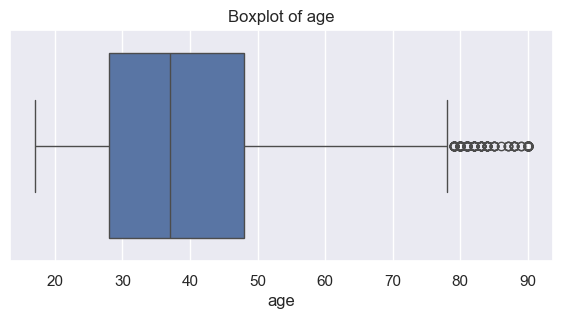

<Figure size 700x300 with 0 Axes>

<Axes: xlabel='hours-per-week'>

Text(0.5, 1.0, 'Boxplot of hours-per-week')

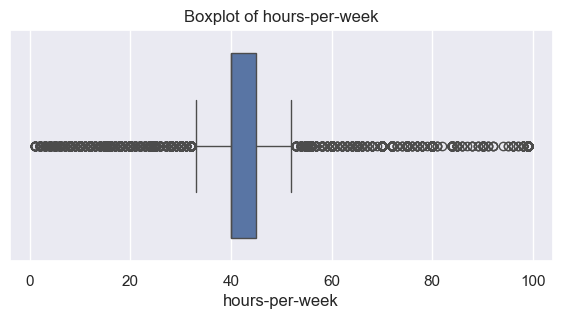

<Figure size 700x300 with 0 Axes>

<Axes: xlabel='fnlwgt'>

Text(0.5, 1.0, 'Boxplot of fnlwgt')

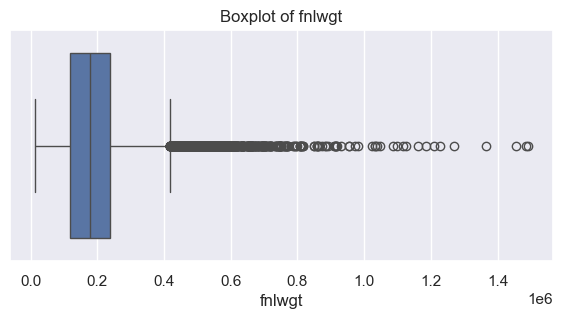

,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers
0,age,28.0,48.00,20.00,-2.000,78.000,215
1,hours-per-week,40.0,45.00,5.00,32.500,52.500,13486
2,fnlwgt,117555.0,237606.25,120051.25,-62521.875,417683.125,1453


In [41]:

iqr_results = []

for col in ["age", "hours-per-week", "fnlwgt"]:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_no_duplicates[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

    q1 = df_no_duplicates[col].quantile(0.25)
    q3 = df_no_duplicates[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((df_no_duplicates[col] < lower) | (df_no_duplicates[col] > upper)).sum()

    iqr_results.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": int(outlier_count)
    })

iqr_summary = pd.DataFrame(iqr_results)
iqr_summary


## Part 4b — Should we remove outliers?

### Tasks
1. Focus on the column `hours-per-week`.
2. Use the IQR rule to create a filtered dataframe called `df_hours_filtered`.
3. Compare:
   - the shape before and after filtering;
   - the mean and median of `hours-per-week` before and after filtering.
4. Write a short comment: does filtering change the variable strongly?


In [42]:

q1 = df_no_duplicates["hours-per-week"].quantile(0.25)
q3 = df_no_duplicates["hours-per-week"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_hours_filtered = df_no_duplicates[
    (df_no_duplicates["hours-per-week"] >= lower) &
    (df_no_duplicates["hours-per-week"] <= upper)
].copy()

df_no_duplicates.shape
df_hours_filtered.shape

df_no_duplicates["hours-per-week"].agg(["mean", "median"])
df_hours_filtered["hours-per-week"].agg(["mean", "median"])


(48790, 15)

(35304, 15)

mean      40.425886
median    40.000000
Name: hours-per-week, dtype: float64

mean      41.564469
median    40.000000
Name: hours-per-week, dtype: float64

**Short comment:**  
Filtering may change the mean more than the median.  
This is typical because the mean is more sensitive to extreme values.


## Part 5 — Cleaning categorical values

In many real datasets, category names are not always consistent:
- extra spaces,
- upper/lower case differences,
- slightly different spellings.

The Adult dataset is already relatively clean, so here we will **simulate** a few inconsistencies.

### Tasks
1. Create `df_categories_dirty` from `df_no_duplicates`.
2. In the column `sex`, replace a few values:
   - `"Male"` → `" male "` for the first 3 matching rows;
   - `"Female"` → `"FEMALE"` for the first 3 matching rows.
3. Display the unique values of `sex`.
4. Clean the column by:
   - stripping spaces;
   - converting to lowercase;
   - mapping values back to standardized labels (`"Male"` and `"Female"`).
5. Check the unique values again.


In [43]:
df_categories_dirty = df_no_duplicates.copy()

# Convert to object type to make manual modifications easier
df_categories_dirty["sex"] = df_categories_dirty["sex"].astype("object")

# Introduce a few inconsistent values
male_idx = df_categories_dirty.index[df_categories_dirty["sex"] == "Male"][:3]
female_idx = df_categories_dirty.index[df_categories_dirty["sex"] == "Female"][:3]

df_categories_dirty.loc[male_idx, "sex"] = " male "
df_categories_dirty.loc[female_idx, "sex"] = "FEMALE"

print("Unique values before cleaning:")
print(df_categories_dirty["sex"].unique())

# Clean the column

df_categories_dirty["sex"] = (
    df_categories_dirty["sex"]
    .str.strip()
    .str.lower()
    .map({"male": "Male", "female": "Female"})
)

print("\nUnique values after cleaning:")
print(df_categories_dirty["sex"].unique())


Unique values before cleaning:
[' male ' 'Male' 'FEMALE' 'Female']

Unique values after cleaning:
['Male' 'Female']


## Part 6 — Encoding categorical variables

Most machine learning models require numerical input.  
For non-ordered categories, a standard choice is **one-hot encoding**.

### Tasks
1. Starting from `df_categories_dirty`, create a new dataframe called `df_encoded`.
2. Separate:
   - the target column `class`;
   - the feature table `X`.
3. Apply one-hot encoding to all categorical columns of `X` using `pd.get_dummies`.
4. Convert the target `class` into a binary numerical target:
   - `<=50K` → 0
   - `>50K` → 1
5. Display:
   - the shape of `X_encoded`;
   - the first few column names;
   - the value counts of the encoded target.
6. Write one sentence: why is one-hot encoding preferred here over label encoding?


In [44]:

df_encoded = df_categories_dirty.copy()

y = df_encoded["class"]
X = df_encoded.drop(columns="class")

X_encoded = pd.get_dummies(X, drop_first=False)

y_encoded = y.map({"<=50K": 0, ">50K": 1})

X_encoded.shape
X_encoded.columns[:20]
y_encoded.value_counts()


(48790, 108)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'workclass_Unknown', 'education_10th',
       'education_11th', 'education_12th', 'education_1st-4th',
       'education_5th-6th'],
      dtype='object')

class
0    37109
1    11681
Name: count, dtype: int64

**Answer:**  
One-hot encoding is preferred because these categories are nominal: they do not have a natural numerical order. Label encoding would introduce artificial ordinal relationships between categories.
In the Adult dataset, a variable like education has an ordinal meaning, but in introductory preprocessing it is often still one-hot encoded for simplicity.

## Part 7 — Scaling numerical variables

Scaling is part of preprocessing, especially when variables have very different magnitudes. It is important because many algorithms rely on distances or numerical optimization. If one feature has much larger values than the others, it can dominate the computation and bias the model. Scaling helps put features on a comparable scale, which often improves training stability and model performance.

In this section, we will compare:
- **standardization** with `StandardScaler`;
- **normalization** with `MinMaxScaler`.

### Tasks
1. Select the following numerical columns:
   - `age`
   - `education-num`
   - `capital-gain`
   - `hours-per-week`
2. Create a small dataframe `X_num` with these columns only.
3. Apply `StandardScaler` and store the result in `X_std`.
4. Apply `MinMaxScaler` and store the result in `X_minmax`.
5. Display the first 5 rows of:
   - the original data;
   - the standardized data;
   - the normalized data.
6. Compare the mean and standard deviation of `X_std`.
7. Compare the minimum and maximum of `X_minmax`.


In [45]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

selected_num_cols = ["age", "education-num", "capital-gain", "hours-per-week"]
X_num = df_encoded[selected_num_cols].copy()

std_scaler = StandardScaler()
X_std = pd.DataFrame(
    std_scaler.fit_transform(X_num),
    columns=X_num.columns,
    index=X_num.index
)

minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X_num),
    columns=X_num.columns,
    index=X_num.index
)

X_num.head()
X_std.head()
X_minmax.head()

X_std.agg(["mean", "std"]).round(3)
X_minmax.agg(["min", "max"]).round(3)


,age,education-num,capital-gain,hours-per-week
0,25,7,0,40
1,38,9,0,50
2,28,12,0,40
3,44,10,7688,40
4,18,10,0,30


,age,education-num,capital-gain,hours-per-week
0,-0.995947,-1.197970,-0.144882,-0.034366
1,-0.047620,-0.419766,-0.144882,0.772567
2,-0.777103,0.747540,-0.144882,-0.034366
3,0.390069,-0.030664,0.886257,-0.034366
4,-1.506585,-0.030664,-0.144882,-0.841299


,age,education-num,capital-gain,hours-per-week
0,0.109589,0.400000,0.000000,0.397959
1,0.287671,0.533333,0.000000,0.500000
2,0.150685,0.733333,0.000000,0.397959
3,0.369863,0.600000,0.076881,0.397959
4,0.013699,0.600000,0.000000,0.295918


,age,education-num,capital-gain,hours-per-week
mean,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0


,age,education-num,capital-gain,hours-per-week
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


**Short comment:**  
It is useful to separate cleaning from modeling because each stage has a different purpose: first we make the data reliable, then we use it in an algorithm.  
A clear preprocessing pipeline makes the work reproducible, easier to debug, and easier to apply later to new data.


## Final reflection

Write a short summary answering the following questions:

1. Which cleaning step seemed the most necessary on this dataset?
2. Which step required the most judgment rather than just code?
3. What is the difference between:
   - detecting an outlier;
   - deciding what to do with an outlier?
4. Why is preprocessing not just a technical detail before machine learning?

You may answer in 5 to 10 lines.


1. The most necessary cleaning step was handling missing categorical values, because several important columns contained missing entries.  
2. Outlier handling required the most judgment, because a detected outlier is not automatically an error.  
3. Detecting an outlier means identifying an unusual value; deciding what to do with it means interpreting its meaning in context and choosing whether to keep, remove, cap, or mark it.  
4. Preprocessing is essential because poor-quality data leads to poor analysis and poor models. Clean and consistent data is a prerequisite for trustworthy results.
